# Prática — Módulo 8: KNN em Análise Preditiva

## **EDA**

In [14]:
# Carregar dataset CSV
import pandas as pd

df = pd.read_csv('/content/dados_e_commerce.csv')
df.head()

,tempo_site,paginas_visitadas,comprou
0,1,2,0
1,2,3,0
2,2,2,0
3,2,1,0
4,2,2,0


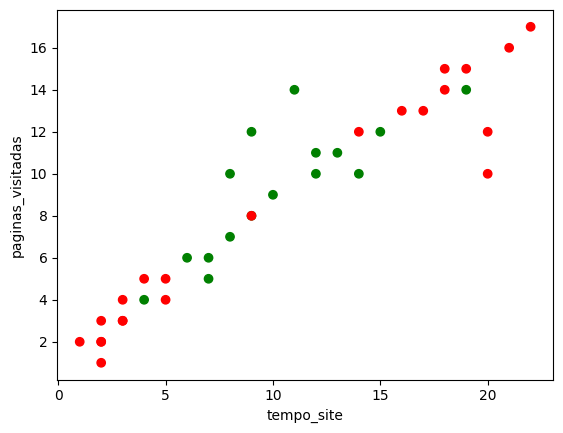

In [15]:
# Scatter plot (visualizar posssível separação)
import matplotlib.pyplot as plt

cores = df['comprou'].map({0: 'red', 1: 'green'})

plt.scatter(df['tempo_site'], df['paginas_visitadas'], c=cores)
plt.xlabel('tempo_site')
plt.ylabel('paginas_visitadas')
plt.show()

### Pergunta
1. Os dados são linearmente separáveis?
2. O que é a variável alvo?
- Variável alvo (y) é a variável que representa o resultado que o modelo deve aprender a prever. Durante o treinamento supervisionado, ela contém os rótulos conhecidos (respostas corretas), que orientam o aprendizado do modelo. Em produção, a variável alvo não está disponível, sendo justamente o valor que o modelo precisa estimar a partir das variáveis de entrada.

In [16]:
# Separar variáveis explicativas e variável alvo
X = df[['tempo_site', 'paginas_visitadas']]
y = df['comprou']

# Dividir dados em treino e teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [17]:
# Escalonar as variáveis explicativas (features)
# Média = 0 | Desvio padrão = 1
from sklearn.preprocessing import StandardScaler
scaler_std = StandardScaler()

X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

### Pergunta
3. Porque escalonamos apenas as variáveis explicativas?

## **KNN**

In [18]:
# "Treinar" o modelo KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
knn.fit(X_train_std, y_train)   # Usar os dados escalonados

KNeighborsClassifier(metric='euclidean', n_neighbors=1)

### Pergunta
4. Se o KNN é um modelo de lazy learning, o que de fato acontece na etapa de ‘treinamento’?
- No KNN, apesar de ser um modelo lazy learning, a etapa chamada de ‘treinamento’ não envolve aprendizado de parâmetros. O que ocorre nessa etapa é basicamente o armazenamento dos dados de treino (X e y) e, em algumas implementações, a organização desses dados em estruturas de busca eficientes. O aprendizado propriamente dito acontece apenas no momento da predição, quando o modelo calcula as distâncias e toma a decisão com base nos vizinhos mais próximos.

In [19]:
# Avaliar desempenho
from sklearn.metrics import accuracy_score, confusion_matrix

# Fazer previsões e armazenar
y_pred = knn.predict(X_test_std)

# Gerar dados da matriz
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

accuracy, cm

(0.5833333333333334,
 array([[5, 2],
        [3, 2]]))

### Pergunta
5. Qual foi a acurácia do modelo para K = 1?
6. O valor de acurácia para K = 1 foi bom? Explique.

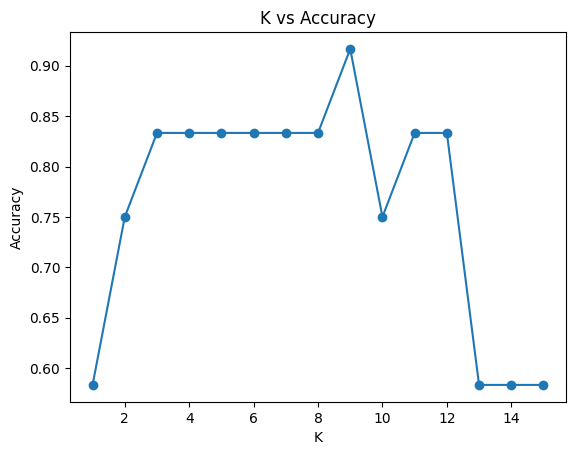

In [20]:
# Testar vários valores de K e plotar desempenho
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

k_values = range(1, 16)
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_std, y_train)
    y_pred = knn.predict(X_test_std)
    scores.append(accuracy_score(y_test, y_pred))

# Plot
plt.plot(k_values, scores, marker='o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('K vs Accuracy')
plt.show()

### Pergunta
7. Existe alguma lógica clara para o valor de K? Quanto maior melhor etc...?

In [21]:
# "Treinar" o modelo KNN com melhor valor de K
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=9, metric='euclidean')
knn.fit(X_train_std, y_train)   # Usar os dados escalonados


KNeighborsClassifier(metric='euclidean', n_neighbors=9)

In [22]:
# Avaliar desempenho
from sklearn.metrics import accuracy_score, confusion_matrix

# Fazer previsões e armazenar
y_pred = knn.predict(X_test_std)

# Gerar dados da matriz
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

accuracy, cm


(0.9166666666666666,
 array([[6, 1],
        [0, 5]]))

### Pergunta
8. O que significa a acurácia de 0.9167 neste contexto?
9. Na matriz [[6, 1], [0, 5]], o que representa a primeira linha (classe 0) e a segunda linha (classe 1) no nosso dataset?
10. Com base na matriz [[6, 1], [0, 5]], identifique TN, FP, FN e TP e interprete no contexto do problema.

In [27]:
# Avaliar métricas principais
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = knn.predict(X_test_std)

print("Acurácia:", accuracy_score(y_test, y_pred))
print("Precisão:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Acurácia: 0.9166666666666666
Precisão: 0.8333333333333334
Recall: 1.0
F1: 0.9090909090909091


### Pergunta
11.	O que a acurácia mede em um modelo de classificação?
12. O que a precisão mede em um modelo de classificação?
13. O que o recall mede e qual a principal diferença em relação à precisão?
14. O que o F1-score mede conceitualmente e por que ele é importante?

## **Regressão Logística**

In [24]:
# Treinar o modelo Regressão Logística
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
logreg.fit(X_train_std, y_train)  # Usar os dados escalonados

LogisticRegression()

In [25]:
# Avaliar desempenho
from sklearn.metrics import accuracy_score, confusion_matrix

# Fazer previsões e armazenar
y_pred = logreg.predict(X_test_std)

# Gerar dados da matriz
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

accuracy, cm

(0.4166666666666667,
 array([[5, 2],
        [5, 0]]))

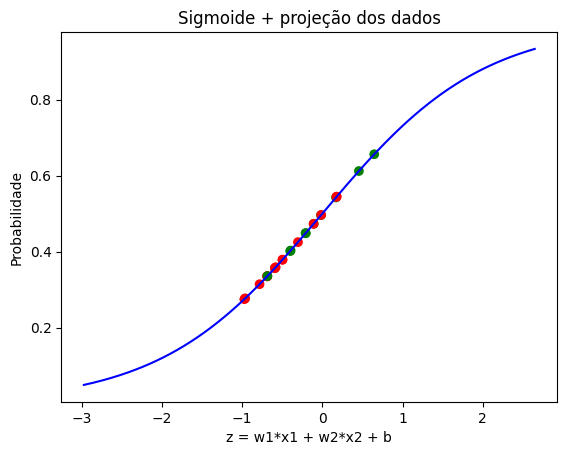

In [26]:
import numpy as np

# Calcular z para TODOS os dados
z_all = np.dot(X_train_std, logreg.coef_[0]) + logreg.intercept_[0]

# Probabilidade correspondente
probs_all = logreg.predict_proba(X_train_std)[:, 1]

# Plot
import matplotlib.pyplot as plt

cores = y_train.map({0: 'red', 1: 'green'})

plt.scatter(z_all, probs_all, c=cores)

# Curva sigmoide teórica
import numpy as np
z_range = np.linspace(z_all.min()-2, z_all.max()+2, 200)
sigmoid = 1 / (1 + np.exp(-z_range))

plt.plot(z_range, sigmoid, color='blue')

plt.xlabel('z = w1*x1 + w2*x2 + b')
plt.ylabel('Probabilidade')
plt.title('Sigmoide + projeção dos dados')
plt.show()

### Pergunta
1. O que representam z, w, x e b na equação z = w₁x₁ + w₂x₂ + b?
2. Os dados são linearmente separáveis no espaço z?
3. Existe um limiar de decisão que separa bem as classes?
4. Por que o KNN conseguiu desempenho superior nesse conjunto de dados?
